# **Phishing Website Detection using Machine Learning**

## **Data Science in Cyber - Final Project**



**Source:  Phishing Website Detection by Machine Learning Techniques**


### **Introduction:**

Phishing is one of the most common cybersecurity threats. Attackers often build fake websites that look like real ones to trick people into giving away sensitive information like usernames, passwords, or financial details.

In this project, the aim is to recreate and evaluate an existing machine learning method for detecting phishing websites. After that, several machine learning models will be compared using different evaluation metrics to see which performs best.

**Dataset Description:**

The dataset for this project comes from the Phishing Website Detection by Machine Learning Techniques repository.

Phishing URLs were taken from the PhishTank database, and the legitimate URLs were collected from the University of New Brunswick’s URL dataset.

In total, the dataset includes 10,000 URLs:

-5,000 legitimate URLs

-5,000 phishing URLs

For each URL, 17 handcrafted features were extracted. These features are based on the URL structure, domain details, and some characteristics of the website content. They are used to train machine learning models to classify whether a website is phishing or legitimate.

**Data Loading:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("5.urldata.csv")

print("Dataset Shape:")
print(data.shape)

data.head()

Dataset Shape:
(10000, 18)


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


**Data Understanding:**

In [ ]:
print("Dataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int

**Interpretation:**

The dataset includes 10,000 samples and 18 columns. Out of these, 17 columns are numerical features, and one column (Domain) contains text.

There are no missing values in any of the features, so no imputation or special handling is needed before training the models.

Overall, the dataset is already clean and ready for exploratory analysis and preprocessing.

**Class Distribution Analysis:**

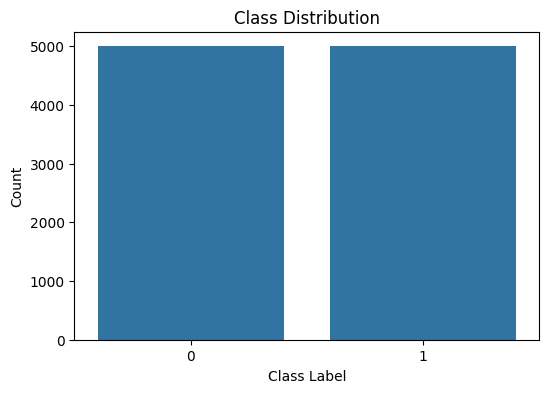

Label
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Label', data=data)

plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

plt.show()

print(data['Label'].value_counts())

**Interpretation:**

The class distribution in the dataset is perfectly balanced, with 5,000 legitimate URLs and 5,000 phishing URLs.

This balance is helpful for machine learning because it means the models won’t be affected by class imbalance during training or evaluation. As a result, there’s no need to use resampling methods like oversampling or undersampling.

**Correlation Analysis:**

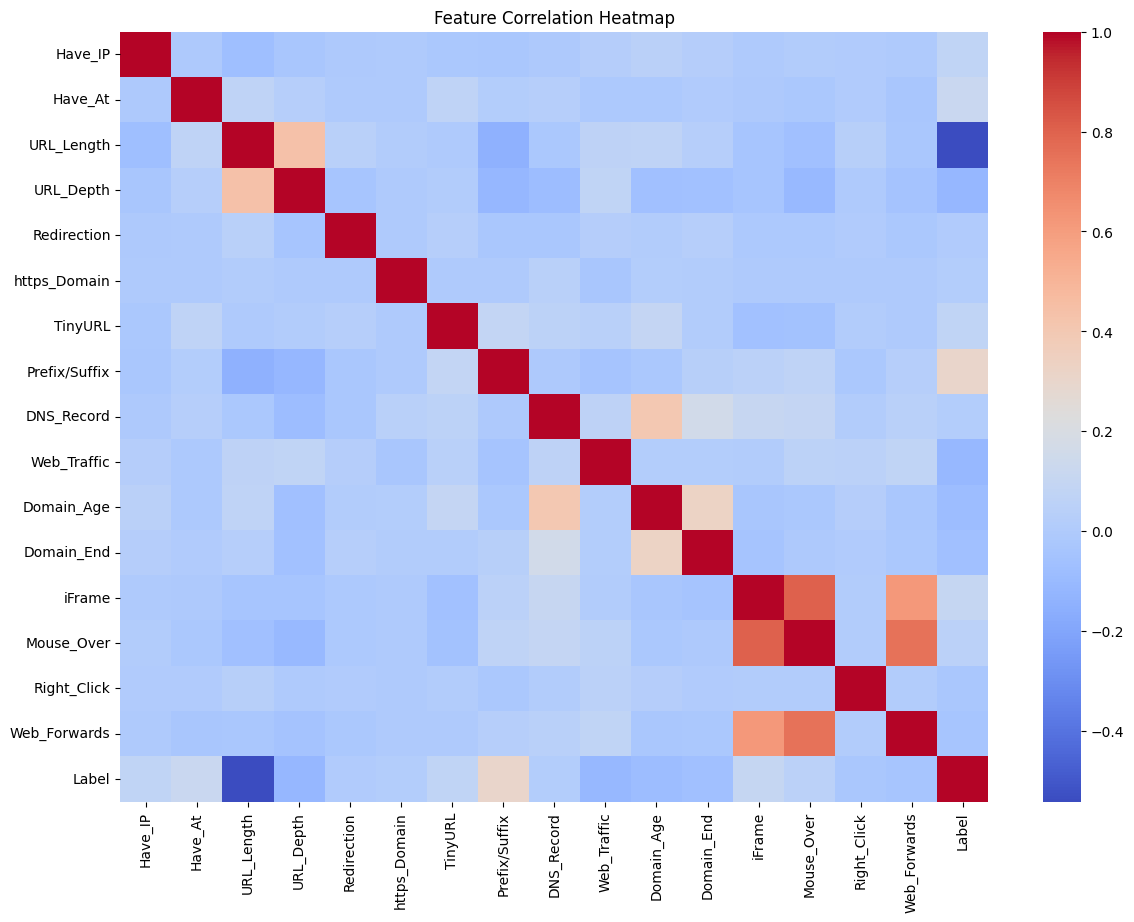

In [ ]:
plt.figure(figsize=(14,10))

correlationMatrix = data.drop("Domain", axis=1).corr()

sns.heatmap(
    correlationMatrix,
    annot=False,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

**Interpretation:**

The correlation heatmap shows that most features have only weak relationships with each other, meaning the dataset doesn’t suffer from strong multicollinearity.

Some feature pairs do show moderate positive correlations. For example, URL_Length and URL_Depth are positively related, which makes sense because longer URLs usually have more directory levels.

There is also a noticeable correlation between Domain_Age and Domain_End, since both are tied to domain registration details.

Overall, the features seem to provide different types of information, which is useful for training machine learning models.

**Feature Distributions:**

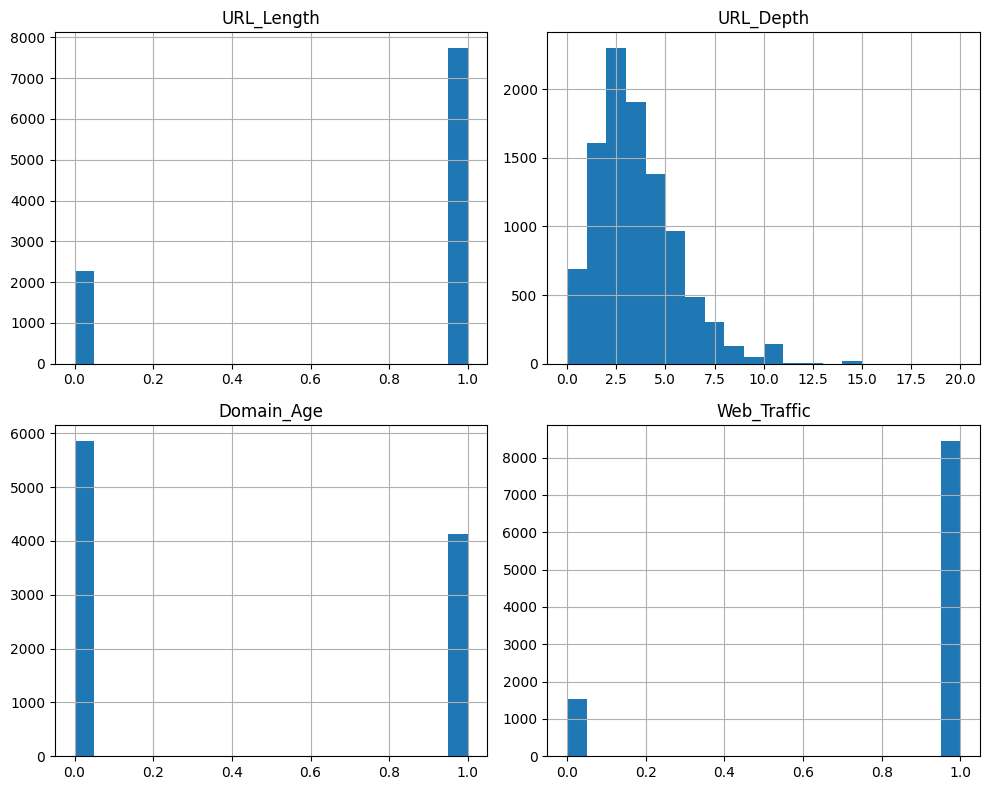

In [ ]:
selectedFeatures = [
    "URL_Length",
    "URL_Depth",
    "Domain_Age",
    "Web_Traffic"
]

data[selectedFeatures].hist(
    figsize=(10,8),
    bins=20
)

plt.tight_layout()
plt.show()

**Interpretation:**

The feature distributions show that some variables, like URL_Length, Domain_Age, and Web_Traffic, were turned into binary features during feature engineering.

This means the original author used rule‑based thresholds instead of keeping the continuous values. While this makes the dataset easier to work with, it can also lead to some loss of information.

On the other hand, URL_Depth is still a numerical feature and has a wider range, with most URLs having between 2 and 5 directory levels.

**Feature Correlation with the Target Variable:**

In [ ]:
targetCorrelation = correlationMatrix["Label"].sort_values(
    ascending=False
)

print(targetCorrelation)

Label            1.000000
Prefix/Suffix    0.302705
Have_At          0.118419
iFrame           0.098446
Have_IP          0.074367
TinyURL          0.072921
Mouse_Over       0.051338
DNS_Record       0.015943
https_Domain     0.014144
Redirection      0.002600
Right_Click     -0.026467
Web_Forwards    -0.041376
Domain_End      -0.068556
Domain_Age      -0.085077
Web_Traffic     -0.108793
URL_Depth       -0.119707
URL_Length      -0.541287
Name: Label, dtype: float64


**Interpretation:**

The strongest correlation with the target variable is seen in URL_Length (-0.541), which suggests that URL length is one of the most useful features in the dataset.

Prefix/Suffix also has a noticeable positive correlation (0.303), meaning that domains containing hyphens are more likely to be linked to phishing websites.

Most of the other features show only weak correlations with the target. This means that phishing detection can’t rely on just one feature — it works better when multiple features are combined through machine learning models.

**Data Preprocessing:**

In [ ]:
X = data.drop(["Domain","Label"], axis=1)

y = data["Label"]

print("Features Shape:")
print(X.shape)

print("\nLabels Shape:")
print(y.shape)

Features Shape:
(10000, 16)

Labels Shape:
(10000,)


The Domain column was removed because it contains text and can’t be directly used by the machine learning models.

The remaining features were saved in X, and the target variable (Label) was stored in y.

**Train/Test Split:**

In [ ]:
from sklearn.model_selection import train_test_split

XTrain, XTest, yTrain, yTest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:")
print(XTrain.shape)

print("\nTest Set Shape:")
print(XTest.shape)

Training Set Shape:
(8000, 16)

Test Set Shape:
(2000, 16)


**Interpretation:**

The dataset was split into training and testing sets using an 80%-20% ratio.

Stratified sampling was applied to make sure the class balance stayed the same in both sets.

**Training \Test Labels Distribution:**

In [ ]:
print("Training Labels Distribution:")
print(yTrain.value_counts())

print("\nTest Labels Distribution:")
print(yTest.value_counts())

Training Labels Distribution:
Label
0    4000
1    4000
Name: count, dtype: int64

Test Labels Distribution:
Label
0    1000
1    1000
Name: count, dtype: int64


**Interpretation:**

The dataset was split into training and testing sets using an 80%–20% ratio. This resulted in 8,000 samples for training and 2,000 samples for testing.

Stratified sampling was used to keep the same class distribution in both sets, so phishing and legitimate URLs are represented equally in the training and test data.


## **Logistic Regression:**

**Description:**

Logistic regression is one of the most widely used classification algorithms. It serves as a robust baseline model and provides an interpretable approach to binary classification problems such as phishing website detection.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logisticModel = LogisticRegression(max_iter=1000)

logisticModel.fit(XTrain, yTrain)

logisticPredictions = logisticModel.predict(XTest)

logisticAccuracy = accuracy_score(
    yTest,
    logisticPredictions
)

print("Logistic Regression Accuracy:")
print(logisticAccuracy)

Logistic Regression Accuracy:
0.7975


**Interpretation:**

The Logistic Regression model achieved an accuracy of 79.75% on the test set.

This model provides a simple baseline for comparison, but its accuracy is lower than that of the more advanced models used in the original project. This indicates that phishing website detection may require more complex models that can capture non-linear patterns in the data.


**Evaluation Metrics:**

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

logisticPrecision = precision_score(
    yTest,
    logisticPredictions
)

logisticRecall = recall_score(
    yTest,
    logisticPredictions
)

logisticF1 = f1_score(
    yTest,
    logisticPredictions
)

print("Accuracy :", round(logisticAccuracy,4))
print("Precision:", round(logisticPrecision,4))
print("Recall   :", round(logisticRecall,4))
print("F1 Score :", round(logisticF1,4))

Accuracy : 0.7975
Precision: 0.9268
Recall   : 0.646
F1 Score : 0.7613


**Interpretation:**

The Logistic Regression model achieved an accuracy of **79.75%**.

The precision is high (**92.68%**), which means that most websites predicted as phishing were actually phishing websites. However, the recall is lower (**64.60%**), meaning that the model missed many phishing websites.

Overall, Logistic Regression works as a good baseline model, but it may not be the best choice for phishing detection since detecting as many phishing websites as possible is very important.


**Confusion Matrix:**

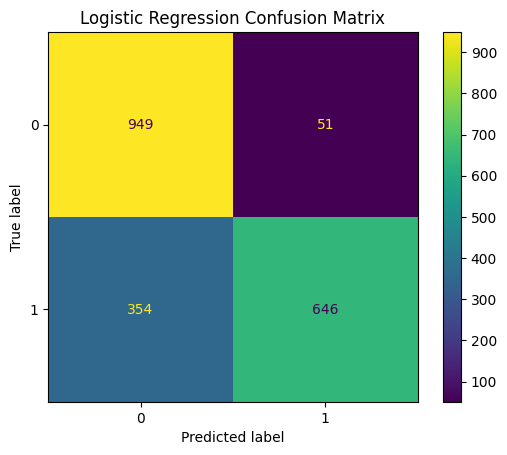

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

confusionMatrix = confusion_matrix(
    yTest,
    logisticPredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=confusionMatrix
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

**Interpretation:**

The confusion matrix shows that the Logistic Regression model correctly classified 949 legitimate websites and 646 phishing websites.

It incorrectly classified only 51 legitimate websites as phishing, which explains the high precision. However, it missed 354 phishing websites, leading to a lower recall.

Overall, the model makes few false alarms, but it misses many phishing websites. This means it is not the best model when the goal is to detect as many phishing attacks as possible.

## **Decision Tree**

**Description :**

Decision Tree is a supervised machine learning algorithm that classifies data by learning a series of decision rules from the training dataset. It is easy to interpret and can capture non-linear relationships between the features.

**Training:**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decisionTreeModel = DecisionTreeClassifier(
    random_state=42
)

decisionTreeModel.fit(
    XTrain,
    yTrain
)

decisionTreePredictions = decisionTreeModel.predict(
    XTest
)

decisionTreeAccuracy = accuracy_score(
    yTest,
    decisionTreePredictions
)

print("Decision Tree Accuracy:")
print(decisionTreeAccuracy)

Decision Tree Accuracy:
0.865


### Interpretation

The Decision Tree model achieved an accuracy of **86.50%** on the test set.

Compared to Logistic Regression, the Decision Tree gave better accuracy. This shows that it can learn more complex patterns in the data, making it a better model for phishing website classification.


**Evaluation Metrics:**

In [ ]:
decisionTreePrecision = precision_score(
    yTest,
    decisionTreePredictions
)

decisionTreeRecall = recall_score(
    yTest,
    decisionTreePredictions
)

decisionTreeF1 = f1_score(
    yTest,
    decisionTreePredictions
)

print("Accuracy :", round(decisionTreeAccuracy,4))
print("Precision:", round(decisionTreePrecision,4))
print("Recall   :", round(decisionTreeRecall,4))
print("F1 Score :", round(decisionTreeF1,4))

Accuracy : 0.865
Precision: 0.9254
Recall   : 0.794
F1 Score : 0.8547


### Interpretation

The Decision Tree model achieved an accuracy of **86.50%**, which is better than the Logistic Regression model.

The precision is still very high (**92.54%**), so most websites predicted as phishing were actually phishing websites. The recall also increased to **79.40%**, which means the model detected more phishing websites than Logistic Regression.

The higher F1-score (**85.47%**) shows that the model has a better balance between precision and recall, making it a better choice for this dataset.


**Confusion Matrix:**

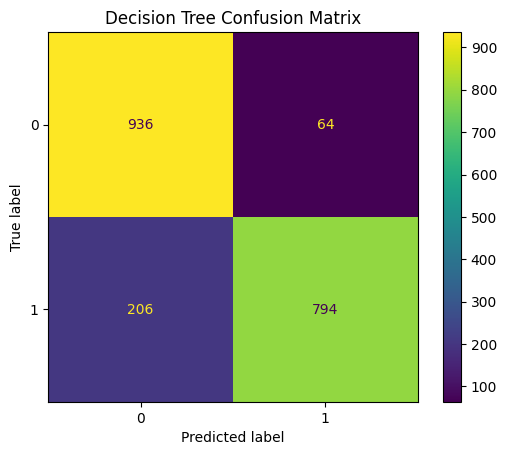

In [ ]:
decisionTreeMatrix = confusion_matrix(
    yTest,
    decisionTreePredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=decisionTreeMatrix
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows that the Decision Tree model correctly classified **936** legitimate websites and **794** phishing websites.

Compared to Logistic Regression, the Decision Tree detected more phishing websites and missed fewer phishing attacks. Although it made a few more false positives, the improvement in phishing detection is much larger.

Overall, the Decision Tree gives a better balance between precision and recall, making it a better model for this dataset.


## **Random Forest**

 **Description :**

Random Forest is a machine learning model that builds many decision trees and combines their predictions. This usually gives better accuracy and helps reduce overfitting compared to using a single Decision Tree.


**Training:**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

randomForestModel = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

randomForestModel.fit(
    XTrain,
    yTrain
)

randomForestPredictions = randomForestModel.predict(
    XTest
)

randomForestAccuracy = accuracy_score(
    yTest,
    randomForestPredictions
)

print("Random Forest Accuracy:")
print(randomForestAccuracy)

Random Forest Accuracy:
0.867


### Interpretation

The Random Forest model achieved an accuracy of **86.70%** on the test set.

It achieved the highest accuracy among all the models. Using multiple decision trees helped the model perform slightly better than a single Decision Tree.


**Evaluation Metrics:**

In [ ]:
randomForestPrecision = precision_score(
    yTest,
    randomForestPredictions
)

randomForestRecall = recall_score(
    yTest,
    randomForestPredictions
)

randomForestF1 = f1_score(
    yTest,
    randomForestPredictions
)

print("Accuracy :", round(randomForestAccuracy,4))
print("Precision:", round(randomForestPrecision,4))
print("Recall   :", round(randomForestRecall,4))
print("F1 Score :", round(randomForestF1,4))

Accuracy : 0.867
Precision: 0.9248
Recall   : 0.799
F1 Score : 0.8573


### Interpretation

The Random Forest model achieved the highest accuracy (**86.70%**) among all the models.

It also had the highest recall (**79.90%**) and F1-score (**85.73%**), showing a good balance between detecting phishing websites and making correct predictions.

Although its precision is slightly lower than Logistic Regression, the difference is very small. Overall, Random Forest gave the best performance and was the best model for this dataset.


**Confusion Matrix:**

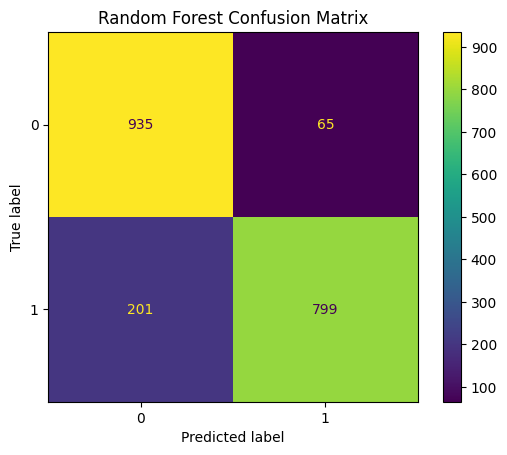

In [ ]:
randomForestMatrix = confusion_matrix(
    yTest,
    randomForestPredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=randomForestMatrix
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows that the Random Forest model correctly classified **935** legitimate websites and **799** phishing websites.

It incorrectly classified **65** legitimate websites as phishing and missed **201** phishing websites.

Compared to the other models, Random Forest detected more phishing websites while still keeping high precision. Overall, it gave the best balance between detecting phishing websites and reducing false alarms.


## **Model Comparison**

**Description :**

The table below compares the performance of all the trained models. It shows the main evaluation metrics: Accuracy, Precision, Recall, and F1-score.


In [ ]:
comparisonTable = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logisticAccuracy,
        decisionTreeAccuracy,
        randomForestAccuracy
    ],
    "Precision": [
        logisticPrecision,
        decisionTreePrecision,
        randomForestPrecision
    ],
    "Recall": [
        logisticRecall,
        decisionTreeRecall,
        randomForestRecall
    ],
    "F1 Score": [
        logisticF1,
        decisionTreeF1,
        randomForestF1
    ]
})

comparisonTable = comparisonTable.round(4)

comparisonTable.reset_index(drop=True, inplace=True)

comparisonTable

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7975,0.9268,0.646,0.7613
1,Decision Tree,0.8650,0.9254,0.794,0.8547
2,Random Forest,0.8670,0.9248,0.799,0.8573


Random Forest achieved the best overall performance and was selected as the final model.

**Accuracy Comparison:**

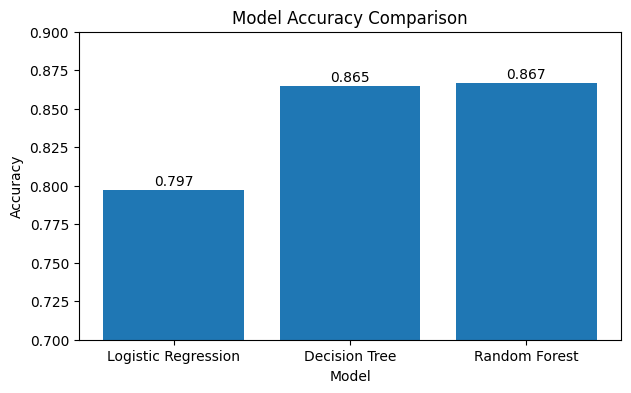

In [ ]:
plt.figure(figsize=(7,4))

bars = plt.bar(
    comparisonTable["Model"],
    comparisonTable["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.7, 0.9)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center"
    )

plt.show()

### Interpretation

The Random Forest model achieved the highest accuracy (**86.70%**).

The Decision Tree model achieved a very similar accuracy (**86.50%**), while Logistic Regression had the lowest accuracy (**79.75%**).

Although the difference between Random Forest and Decision Tree is small, Random Forest also had the highest recall and F1-score. Overall, it gave the best performance and was the best model for phishing website detection.


# Conclusion

In this project, I trained and evaluated three machine learning models for phishing website detection: Logistic Regression, Decision Tree, and Random Forest.

The results showed that the Decision Tree and Random Forest models performed better than Logistic Regression. Among them, Random Forest achieved the best overall performance, with the highest accuracy, recall, and F1-score.

Overall, Random Forest was the best model for this dataset because it provided the best balance between correctly detecting phishing websites and minimizing false predictions.

This project demonstrates that machine learning can effectively detect phishing websites using URL and website-related features. While Logistic Regression provides a simple and interpretable baseline, tree-based models were better at capturing the complex relationships between the features.

In future work, additional ensemble methods such as XGBoost or LightGBM could be evaluated. Hyperparameter tuning could also be applied to further improve the model's performance.